# Hierarchical Clustering

## Overview
Hierarchical Clustering builds a **tree of clusters (dendrogram)** without requiring K to be specified in advance. It comes in two flavors:

### Agglomerative (Bottom-Up) — most common:
1. Start: each point is its own cluster
2. Merge the two **closest** clusters
3. Repeat until one cluster remains
4. Cut the dendrogram at desired height to get K clusters

### Divisive (Top-Down):
1. Start: all points in one cluster
2. Recursively split into smaller clusters

### Linkage Criteria (how to measure cluster distance):
| Linkage | Distance Metric | Cluster Shape |
|---------|----------------|---------------|
| **Single** | Min distance between points | Elongated, chaining |
| **Complete** | Max distance between points | Compact, spherical |
| **Average** | Avg distance between all pairs | Balanced |
| **Ward** | Min increase in total variance | Compact, equal-size |

### Ward Linkage (most popular):
$$\Delta(A,B) = \frac{n_A n_B}{n_A + n_B} \|\mu_A - \mu_B\|^2$$

### Key Advantages over K-Means:
- No need to specify K in advance
- Produces a dendrogram for visual exploration
- Can find non-spherical clusters (with single linkage)
- Deterministic — no random initialization

---
### Topics Covered
1. Dendrogram visualization
2. Agglomerative clustering — step-by-step
3. Linkage comparison (single, complete, average, ward)
4. Cutting the dendrogram to get clusters
5. Connectivity constraints
6. Feature scaling importance
7. Real-world offline-safe dataset — gene expression style
8. Cluster heatmap with dendrogram
9. Evaluation metrics
10. K-Means vs Hierarchical comparison


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)
from sklearn.datasets import make_blobs, make_moons, make_circles
from scipy.cluster.hierarchy import (
    dendrogram, linkage, fcluster, cophenet
)
from scipy.spatial.distance import pdist

COLORS = {
    'primary':   '#2E86AB',
    'secondary': '#E67E22',
    'tertiary':  '#9B59B6',
    'success':   '#27AE60',
    'danger':    '#E74C3C',
    'neutral':   '#7F8C8D',
}
CLUSTER_COLORS = ['#E74C3C','#2E86AB','#27AE60','#E67E22',
                  '#9B59B6','#F39C12','#1ABC9C','#E91E63']

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('Libraries imported successfully!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Libraries imported successfully!
NumPy  : 1.26.4
Pandas : 2.3.3


## 2. Agglomerative Clustering — Step-by-Step Visualization

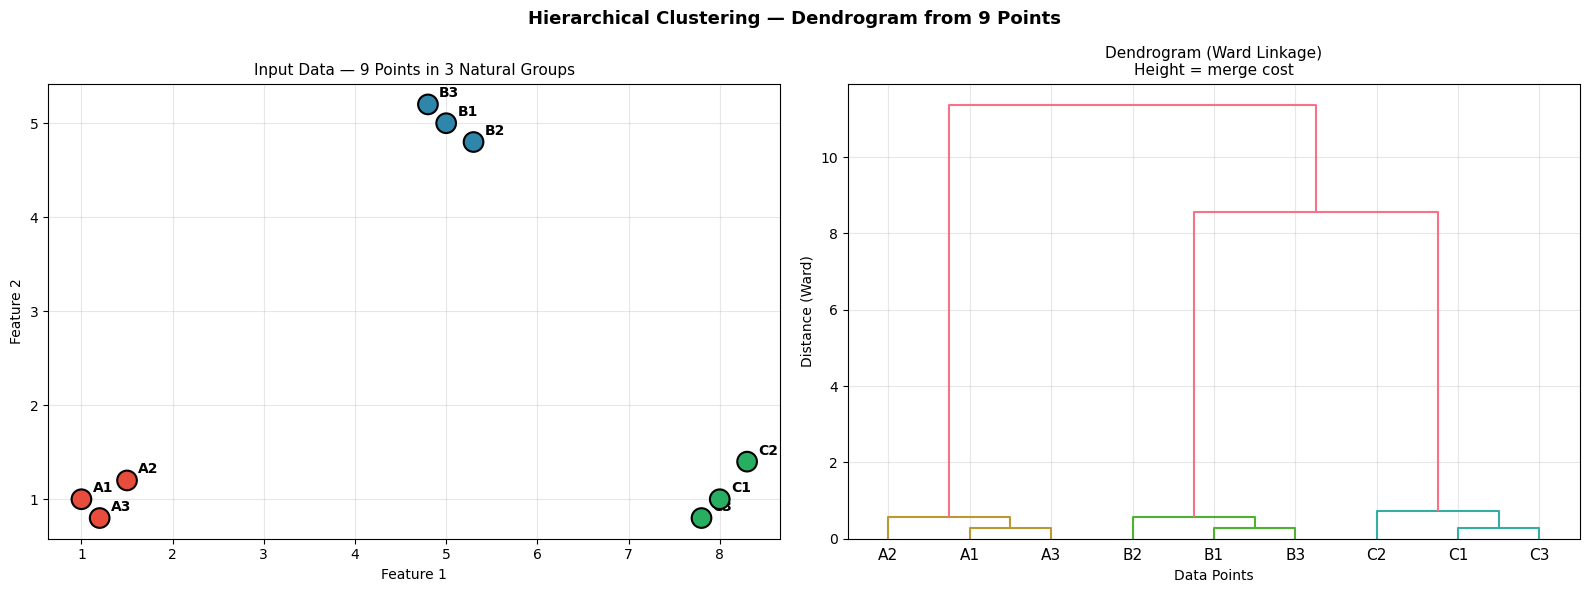

Reading the dendrogram:
  - Leaves = individual data points
  - Height = distance at which clusters merged
  - Horizontal line cut -> number of clusters = branches crossed


In [2]:
# Small dataset to trace merges clearly
np.random.seed(42)
X_small = np.array([
    [1.0, 1.0], [1.5, 1.2], [1.2, 0.8],   # Group A
    [5.0, 5.0], [5.3, 4.8], [4.8, 5.2],   # Group B
    [8.0, 1.0], [8.3, 1.4], [7.8, 0.8],   # Group C
])
labels_small = ['A1','A2','A3','B1','B2','B3','C1','C2','C3']

Z_small = linkage(X_small, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter
group_colors = ['#E74C3C']*3 + ['#2E86AB']*3 + ['#27AE60']*3
axes[0].scatter(X_small[:, 0], X_small[:, 1],
                c=group_colors, s=200, edgecolors='black', linewidths=1.5, zorder=5)
for i, lbl in enumerate(labels_small):
    axes[0].annotate(lbl, X_small[i], textcoords='offset points',
                     xytext=(8, 5), fontsize=10, fontweight='bold')
axes[0].set_title('Input Data — 9 Points in 3 Natural Groups', fontsize=11)
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')

# Dendrogram
dendrogram(Z_small, labels=labels_small, ax=axes[1],
           color_threshold=4,
           leaf_font_size=11)
axes[1].set_title('Dendrogram (Ward Linkage)\nHeight = merge cost', fontsize=11)
axes[1].set_xlabel('Data Points')
axes[1].set_ylabel('Distance (Ward)')

plt.suptitle('Hierarchical Clustering — Dendrogram from 9 Points',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Reading the dendrogram:')
print('  - Leaves = individual data points')
print('  - Height = distance at which clusters merged')
print('  - Horizontal line cut -> number of clusters = branches crossed')

## 3. Full Dendrogram — Larger Dataset

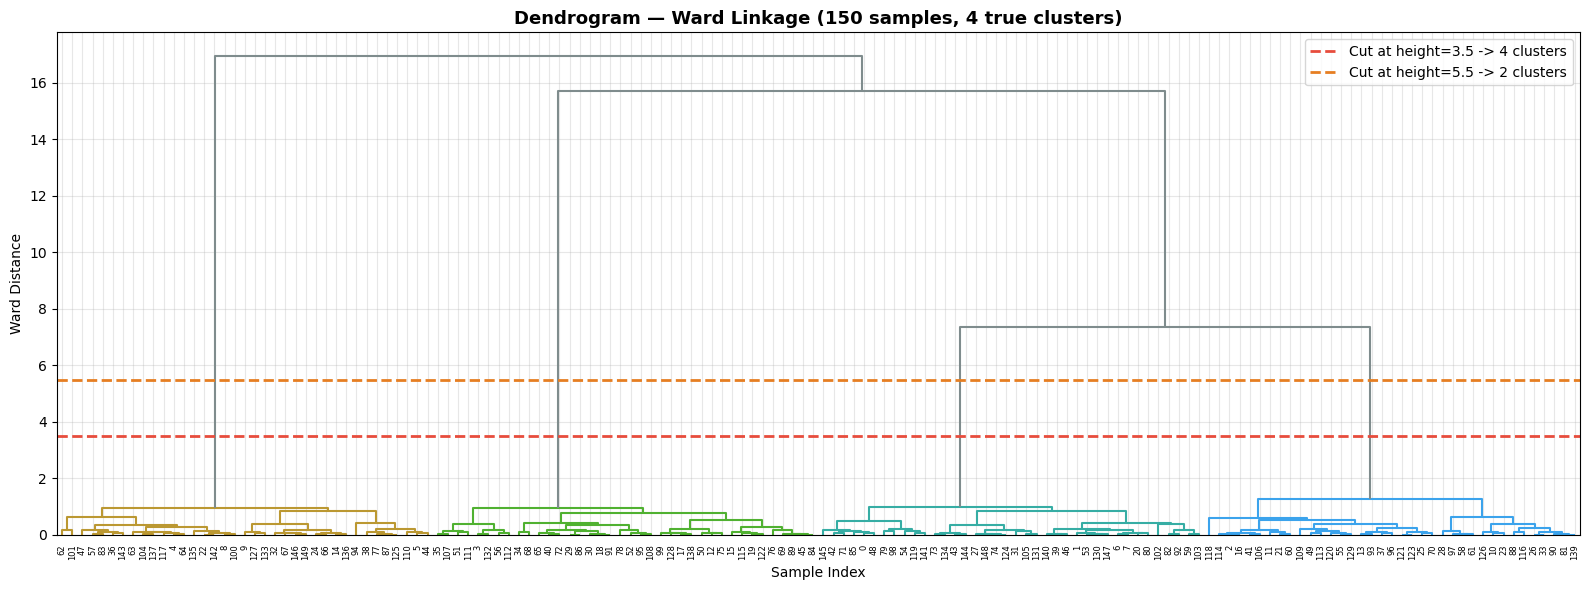

Cophenetic Correlation : 0.9490
(Closer to 1.0 = dendrogram faithfully represents pairwise distances)

How to read the cut lines:
  Red line at 3.5  -> crosses 4 branches -> 4 clusters
  Orange line at 5.5 -> crosses 2 branches -> 2 clusters


In [3]:
np.random.seed(42)
X, y_true = make_blobs(n_samples=150, centers=4,
                        cluster_std=0.8, random_state=42)
sc = StandardScaler()
X_sc = sc.fit_transform(X)

Z = linkage(X_sc, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(Z, ax=ax, color_threshold=3.5,
           leaf_font_size=6, above_threshold_color=COLORS['neutral'])
ax.axhline(y=3.5, color=COLORS['danger'], linestyle='--',
           linewidth=2, label='Cut at height=3.5 -> 4 clusters')
ax.axhline(y=5.5, color=COLORS['secondary'], linestyle='--',
           linewidth=2, label='Cut at height=5.5 -> 2 clusters')
ax.set_title('Dendrogram — Ward Linkage (150 samples, 4 true clusters)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Ward Distance')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Cophenetic correlation — how well dendrogram preserves pairwise distances
coph_corr, _ = cophenet(Z, pdist(X_sc))
print(f'Cophenetic Correlation : {coph_corr:.4f}')
print('(Closer to 1.0 = dendrogram faithfully represents pairwise distances)')
print()
print('How to read the cut lines:')
print('  Red line at 3.5  -> crosses 4 branches -> 4 clusters')
print('  Orange line at 5.5 -> crosses 2 branches -> 2 clusters')

## 4. Cutting the Dendrogram — Getting Cluster Labels

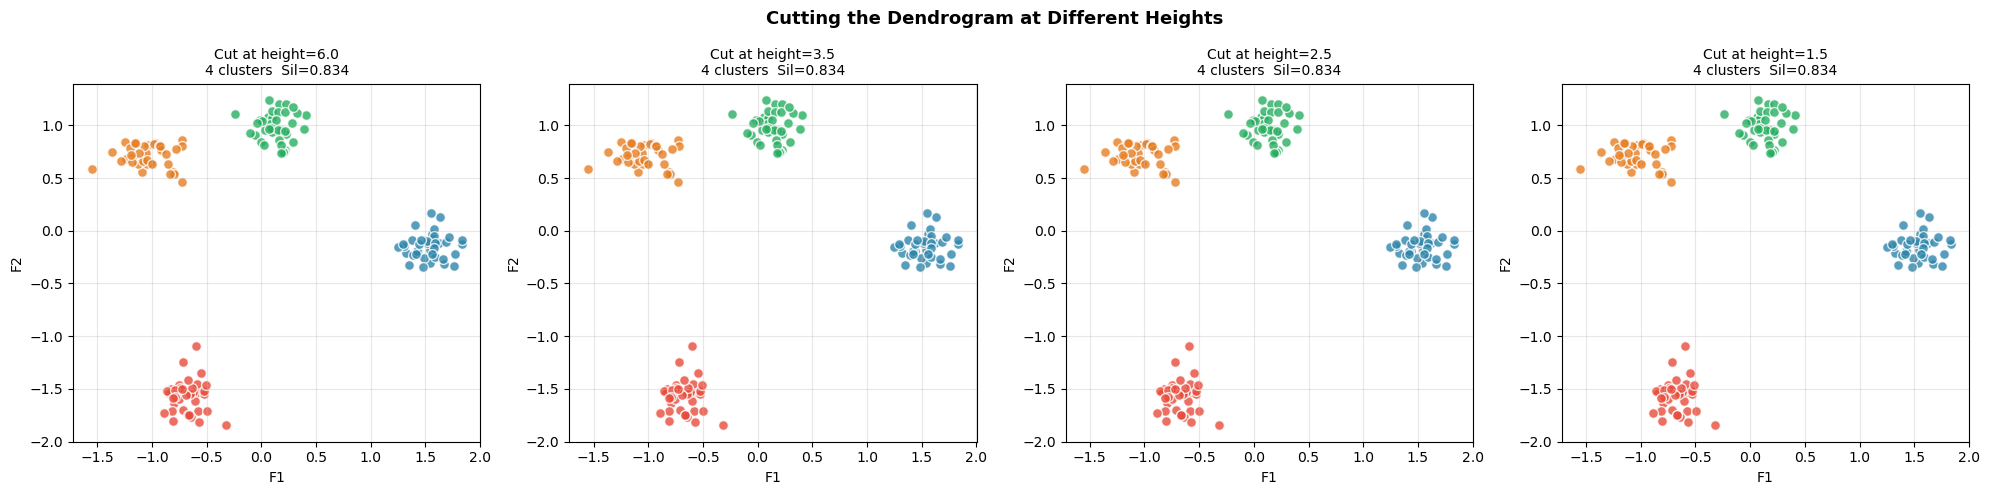

In [4]:
cut_heights = [6.0, 3.5, 2.5, 1.5]
fig, axes   = plt.subplots(1, 4, figsize=(20, 5))

for ax, height in zip(axes, cut_heights):
    labels_cut = fcluster(Z, t=height, criterion='distance') - 1
    n_clust    = len(np.unique(labels_cut))
    sil        = silhouette_score(X_sc, labels_cut) if n_clust > 1 else np.nan

    for k in range(n_clust):
        mask = labels_cut == k
        ax.scatter(X_sc[mask, 0], X_sc[mask, 1],
                   color=CLUSTER_COLORS[k % len(CLUSTER_COLORS)],
                   s=50, alpha=0.8, edgecolors='white')
    ax.set_title(f'Cut at height={height}\n{n_clust} clusters  Sil={sil:.3f}',
                 fontsize=10)
    ax.set_xlabel('F1'); ax.set_ylabel('F2')

plt.suptitle('Cutting the Dendrogram at Different Heights',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Linkage Comparison — Single / Complete / Average / Ward

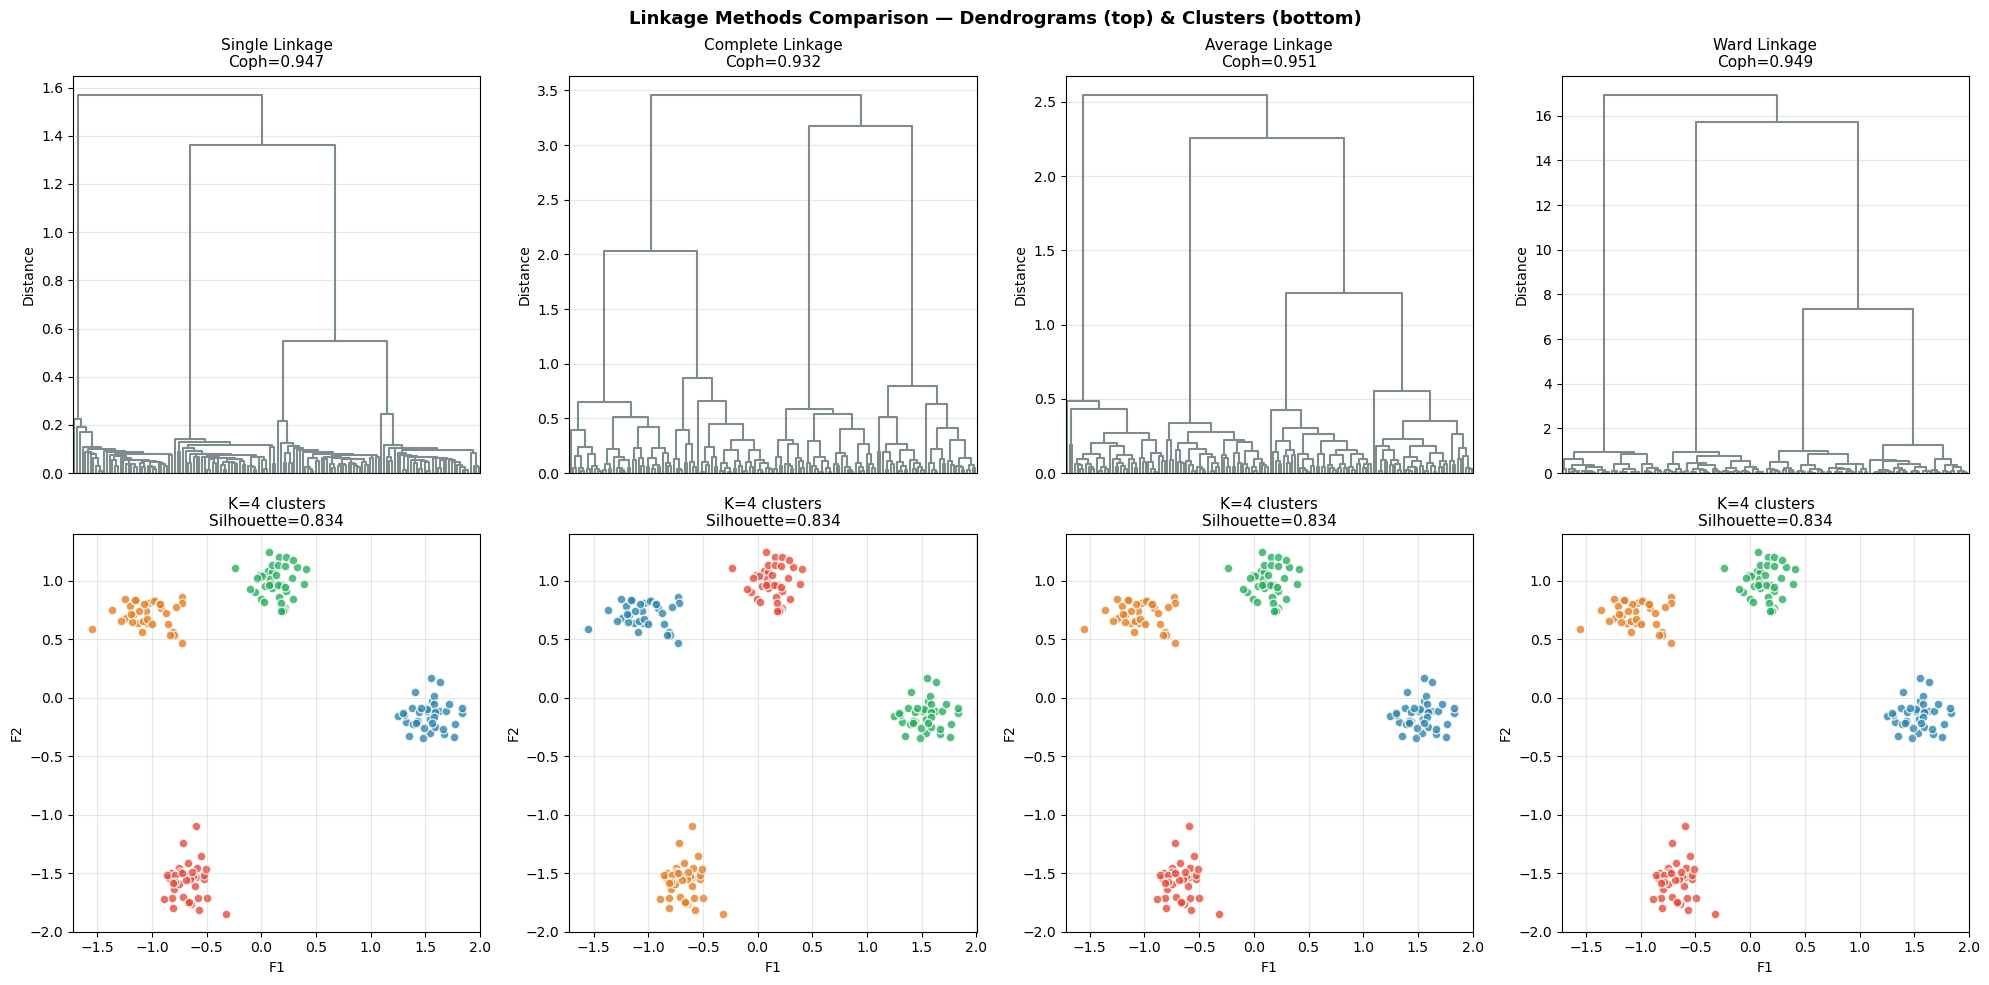

Single   -> chaining effect; can produce elongated clusters
Complete -> compact clusters; sensitive to outliers
Average  -> balanced between single and complete
Ward     -> minimizes variance increase; tends to produce equal-size clusters
           (most commonly used in practice)


In [5]:
linkage_methods = ['single', 'complete', 'average', 'ward']
n_clusters      = 4

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for col, method in enumerate(linkage_methods):
    Z_m    = linkage(X_sc, method=method)
    labels = fcluster(Z_m, t=n_clusters, criterion='maxclust') - 1
    sil    = silhouette_score(X_sc, labels)
    coph, _ = cophenet(Z_m, pdist(X_sc))

    # Dendrogram
    dendrogram(Z_m, ax=axes[0][col], color_threshold=0,
               above_threshold_color=COLORS['neutral'],
               leaf_font_size=0, no_labels=True)
    axes[0][col].set_title(f'{method.capitalize()} Linkage\nCoph={coph:.3f}',
                            fontsize=11)
    axes[0][col].set_ylabel('Distance')

    # Scatter
    for k in range(n_clusters):
        mask = labels == k
        axes[1][col].scatter(X_sc[mask, 0], X_sc[mask, 1],
                             color=CLUSTER_COLORS[k], s=40, alpha=0.8,
                             edgecolors='white')
    axes[1][col].set_title(f'K={n_clusters} clusters\nSilhouette={sil:.3f}',
                            fontsize=11)
    axes[1][col].set_xlabel('F1'); axes[1][col].set_ylabel('F2')

plt.suptitle('Linkage Methods Comparison — Dendrograms (top) & Clusters (bottom)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Single   -> chaining effect; can produce elongated clusters')
print('Complete -> compact clusters; sensitive to outliers')
print('Average  -> balanced between single and complete')
print('Ward     -> minimizes variance increase; tends to produce equal-size clusters')
print('           (most commonly used in practice)')

## 6. Hierarchical vs K-Means on Non-Spherical Data

  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


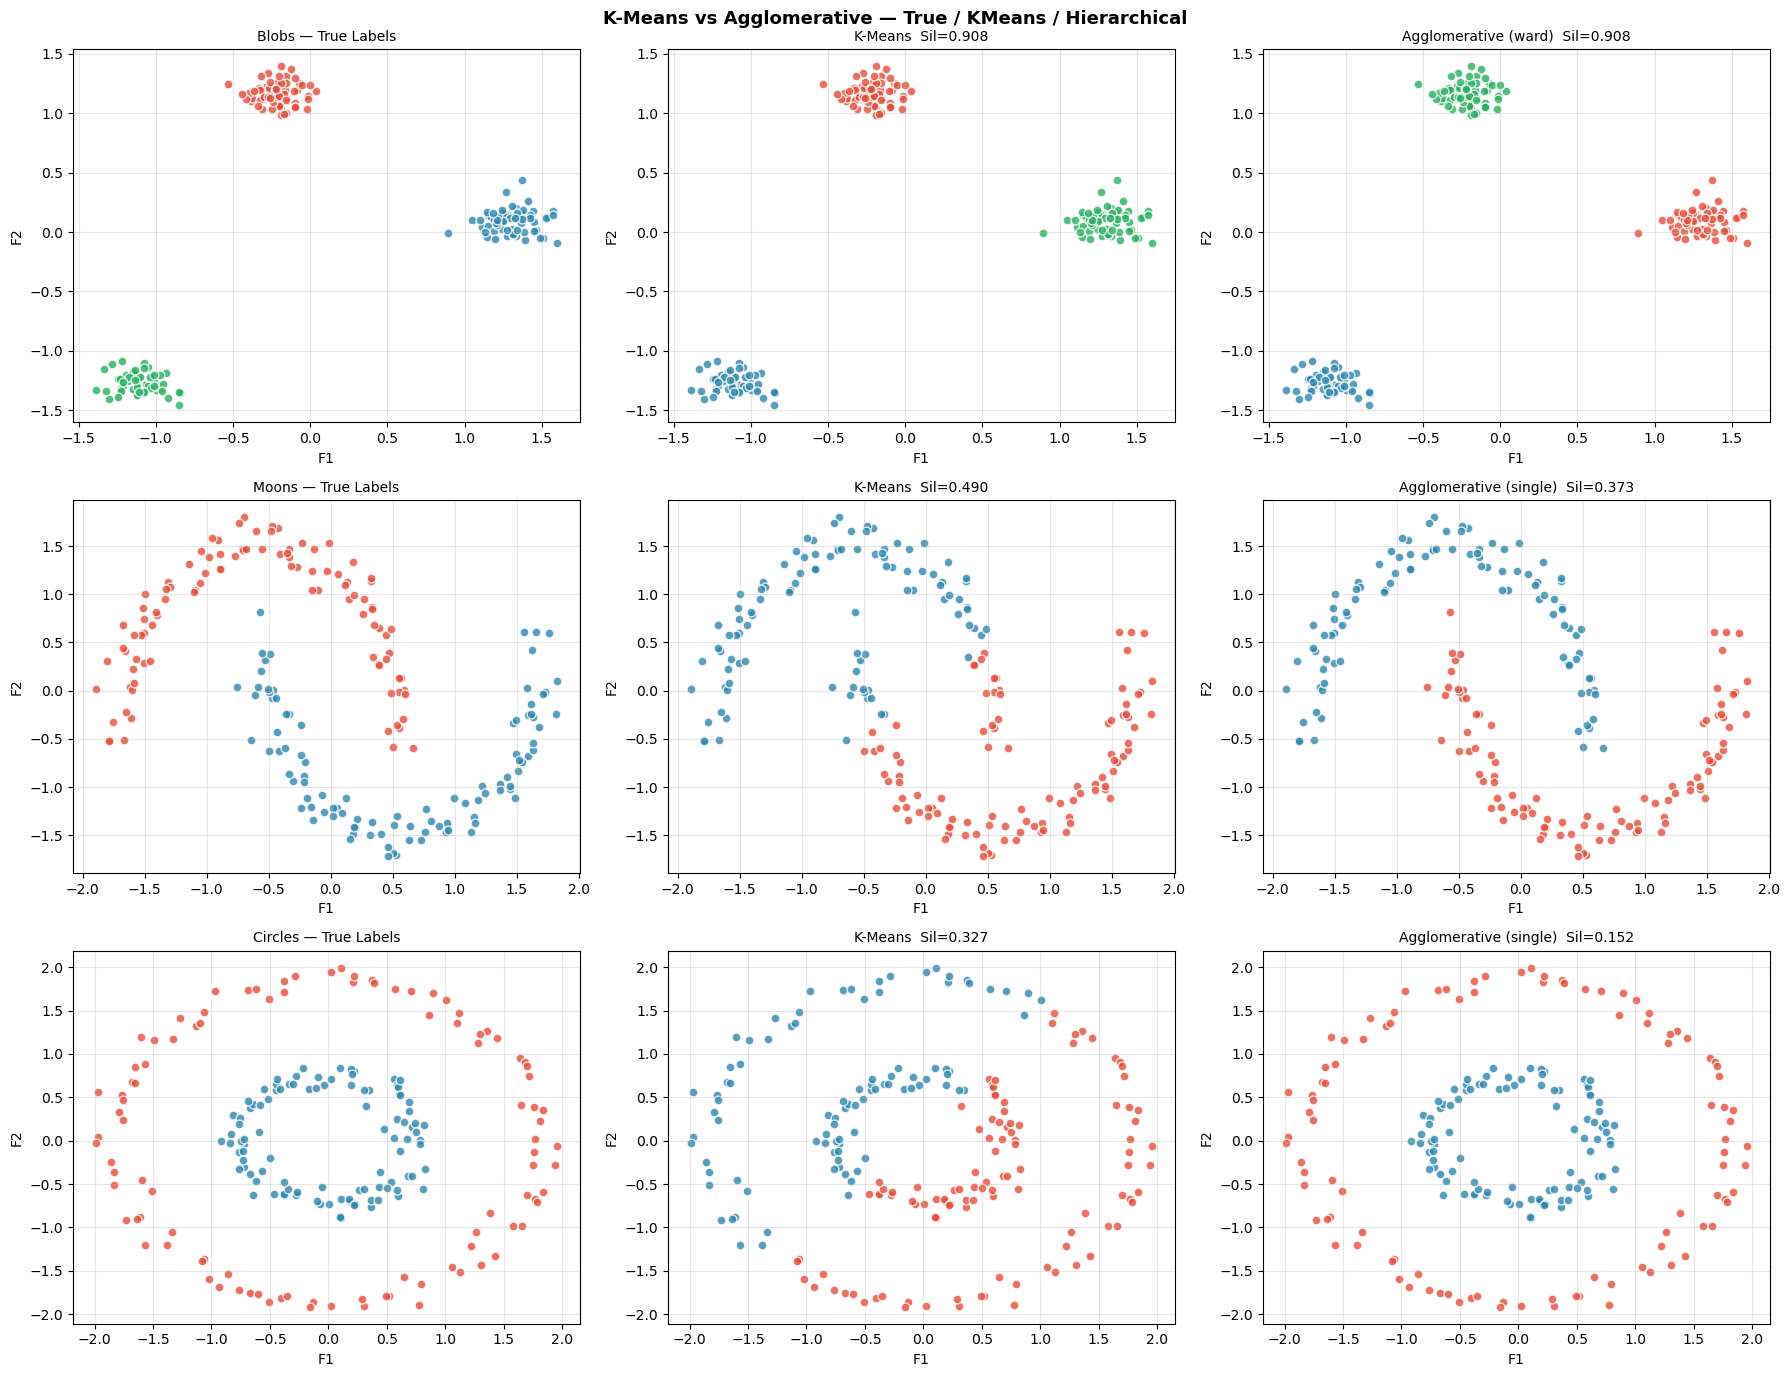

In [6]:
np.random.seed(42)
datasets_ns = {
    'Blobs':   make_blobs(n_samples=200, centers=3, cluster_std=0.6, random_state=42),
    'Moons':   make_moons(n_samples=200, noise=0.07, random_state=42),
    'Circles': make_circles(n_samples=200, noise=0.05, factor=0.4, random_state=42),
}

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for row, (name, (X_ns, y_ns)) in enumerate(datasets_ns.items()):
    X_ns_sc = StandardScaler().fit_transform(X_ns)
    n_k     = len(np.unique(y_ns))

    # True labels
    for k in np.unique(y_ns):
        axes[row][0].scatter(X_ns_sc[y_ns==k, 0], X_ns_sc[y_ns==k, 1],
                             color=CLUSTER_COLORS[k], s=40, alpha=0.8, edgecolors='white')
    axes[row][0].set_title(f'{name} — True Labels', fontsize=10)

    # K-Means
    km = KMeans(n_clusters=n_k, init='k-means++', n_init=10, random_state=42)
    km_pred = km.fit_predict(X_ns_sc)
    km_sil  = silhouette_score(X_ns_sc, km_pred)
    for k in range(n_k):
        axes[row][1].scatter(X_ns_sc[km_pred==k, 0], X_ns_sc[km_pred==k, 1],
                             color=CLUSTER_COLORS[k], s=40, alpha=0.8, edgecolors='white')
    axes[row][1].set_title(f'K-Means  Sil={km_sil:.3f}', fontsize=10)

    # Hierarchical (single linkage for moons/circles)
    link_method = 'single' if name != 'Blobs' else 'ward'
    ac = AgglomerativeClustering(n_clusters=n_k, linkage=link_method)
    ac_pred = ac.fit_predict(X_ns_sc)
    ac_sil  = silhouette_score(X_ns_sc, ac_pred)
    for k in range(n_k):
        axes[row][2].scatter(X_ns_sc[ac_pred==k, 0], X_ns_sc[ac_pred==k, 1],
                             color=CLUSTER_COLORS[k], s=40, alpha=0.8, edgecolors='white')
    axes[row][2].set_title(
        f'Agglomerative ({link_method})  Sil={ac_sil:.3f}', fontsize=10
    )

    for ax in axes[row]:
        ax.set_xlabel('F1'); ax.set_ylabel('F2')

plt.suptitle('K-Means vs Agglomerative — True / KMeans / Hierarchical',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Choosing Number of Clusters from Dendrogram

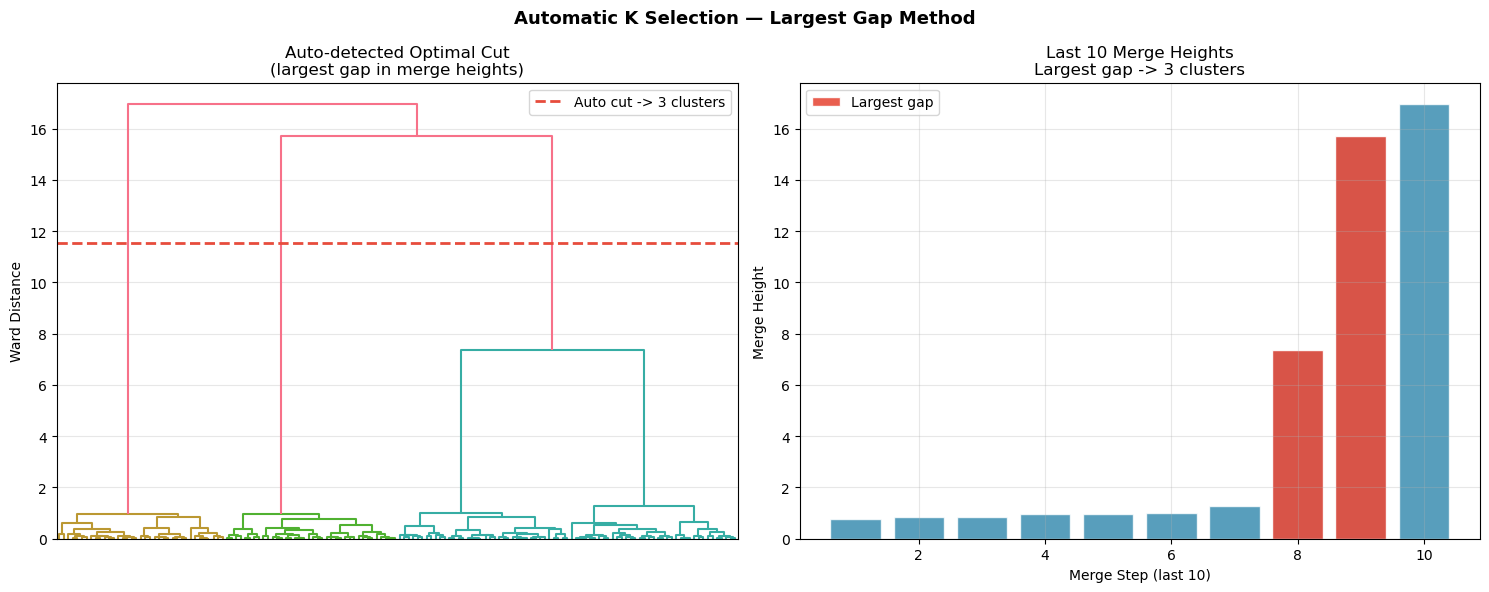

Largest gap found between merge 8 and 9
Auto-suggested number of clusters: 3


In [7]:
# Find the largest gap between consecutive merge heights
last_merges = Z[-10:, 2]   # heights of last 10 merges
gaps        = np.diff(last_merges)
best_cut_idx = np.argmax(gaps)
best_n_clusters = 10 - best_cut_idx

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Full dendrogram with cut
cut_height = (last_merges[best_cut_idx] + last_merges[best_cut_idx+1]) / 2
dendrogram(Z, ax=axes[0], color_threshold=cut_height,
           leaf_font_size=0, no_labels=True)
axes[0].axhline(cut_height, color=COLORS['danger'], linestyle='--',
                linewidth=2, label=f'Auto cut -> {best_n_clusters} clusters')
axes[0].set_title('Auto-detected Optimal Cut\n(largest gap in merge heights)')
axes[0].set_ylabel('Ward Distance')
axes[0].legend()

# Last 10 merges with gap
x_pos = range(1, len(last_merges)+1)
axes[1].bar(x_pos, last_merges, color=COLORS['primary'], edgecolor='white', alpha=0.8)
axes[1].bar([best_cut_idx+1, best_cut_idx+2],
            [last_merges[best_cut_idx], last_merges[best_cut_idx+1]],
            color=COLORS['danger'], edgecolor='white', alpha=0.9,
            label='Largest gap')
axes[1].set_xlabel('Merge Step (last 10)')
axes[1].set_ylabel('Merge Height')
axes[1].set_title(f'Last 10 Merge Heights\nLargest gap -> {best_n_clusters} clusters')
axes[1].legend()

plt.suptitle('Automatic K Selection — Largest Gap Method',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Largest gap found between merge {best_cut_idx+1} and {best_cut_idx+2}')
print(f'Auto-suggested number of clusters: {best_n_clusters}')

## 8. Real-World Offline-Safe Dataset — Patient Health Profiles

Patient dataset shape : (200, 8)


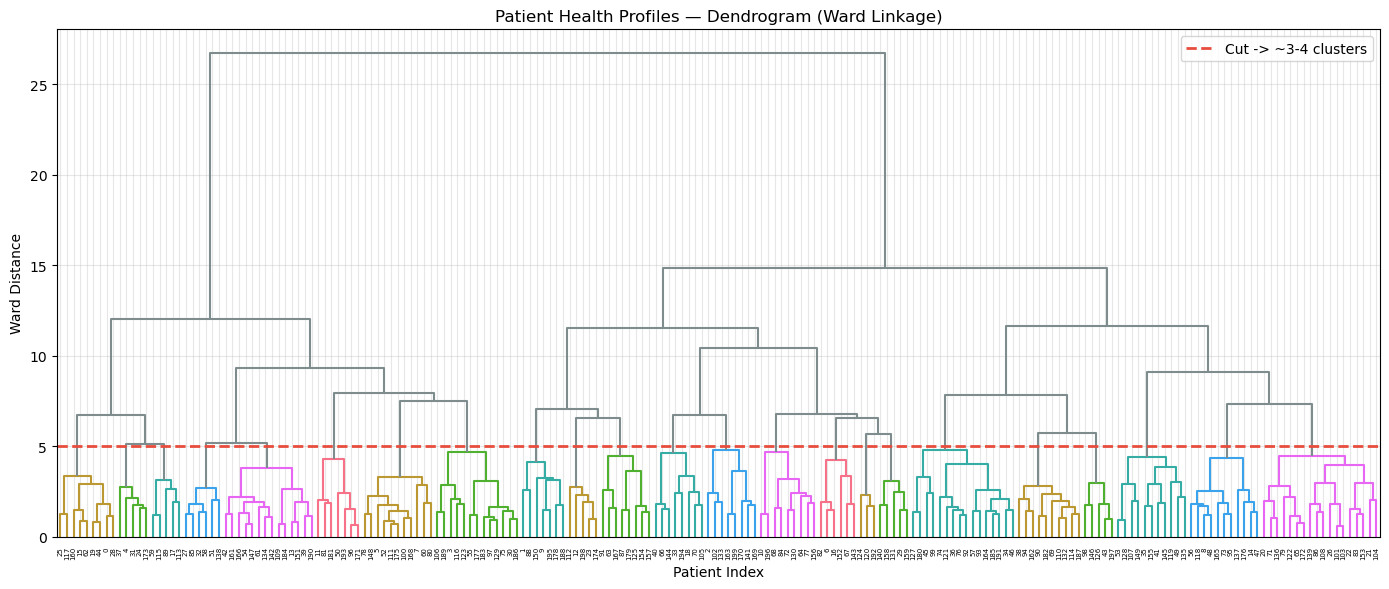

In [8]:
np.random.seed(42)
n_pat = 200

Age          = np.random.randint(25, 80, n_pat).astype(float)
BMI          = np.random.uniform(17, 45, n_pat)
BloodPres    = np.random.uniform(60, 160, n_pat)
Glucose      = np.random.uniform(70, 200, n_pat)
Cholesterol  = np.random.uniform(120, 350, n_pat)
HeartRate    = np.random.uniform(50, 110, n_pat)
Insulin      = np.random.uniform(10, 300, n_pat)
CRP          = np.random.uniform(0, 10, n_pat)

# Inject cluster structure
# Cluster 0 — Healthy young
idx0 = np.random.choice(n_pat, 50, replace=False)
Age[idx0]         = np.random.randint(25, 40, 50)
BMI[idx0]         = np.random.uniform(18, 25, 50)
Glucose[idx0]     = np.random.uniform(70, 100, 50)
Cholesterol[idx0] = np.random.uniform(120, 180, 50)

# Cluster 1 — High-risk elderly
rem = np.setdiff1d(range(n_pat), idx0)
idx1 = np.random.choice(rem, 50, replace=False)
Age[idx1]         = np.random.randint(60, 80, 50)
BMI[idx1]         = np.random.uniform(30, 45, 50)
Glucose[idx1]     = np.random.uniform(140, 200, 50)
Cholesterol[idx1] = np.random.uniform(250, 350, 50)
CRP[idx1]         = np.random.uniform(6, 10, 50)

feat_names_pat = ['Age','BMI','BloodPres','Glucose',
                  'Cholesterol','HeartRate','Insulin','CRP']
X_pat = np.column_stack([Age, BMI, BloodPres, Glucose,
                          Cholesterol, HeartRate, Insulin, CRP])

sc_pat   = StandardScaler()
X_pat_sc = sc_pat.fit_transform(X_pat)

print(f'Patient dataset shape : {X_pat.shape}')

# Build dendrogram
Z_pat = linkage(X_pat_sc, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z_pat, ax=ax, color_threshold=5,
           leaf_font_size=5, above_threshold_color=COLORS['neutral'])
ax.axhline(5, color=COLORS['danger'], linestyle='--',
           linewidth=2, label='Cut -> ~3-4 clusters')
ax.set_title('Patient Health Profiles — Dendrogram (Ward Linkage)', fontsize=12)
ax.set_xlabel('Patient Index')
ax.set_ylabel('Ward Distance')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Cluster Heatmap with Dendrogram (Clustermap)

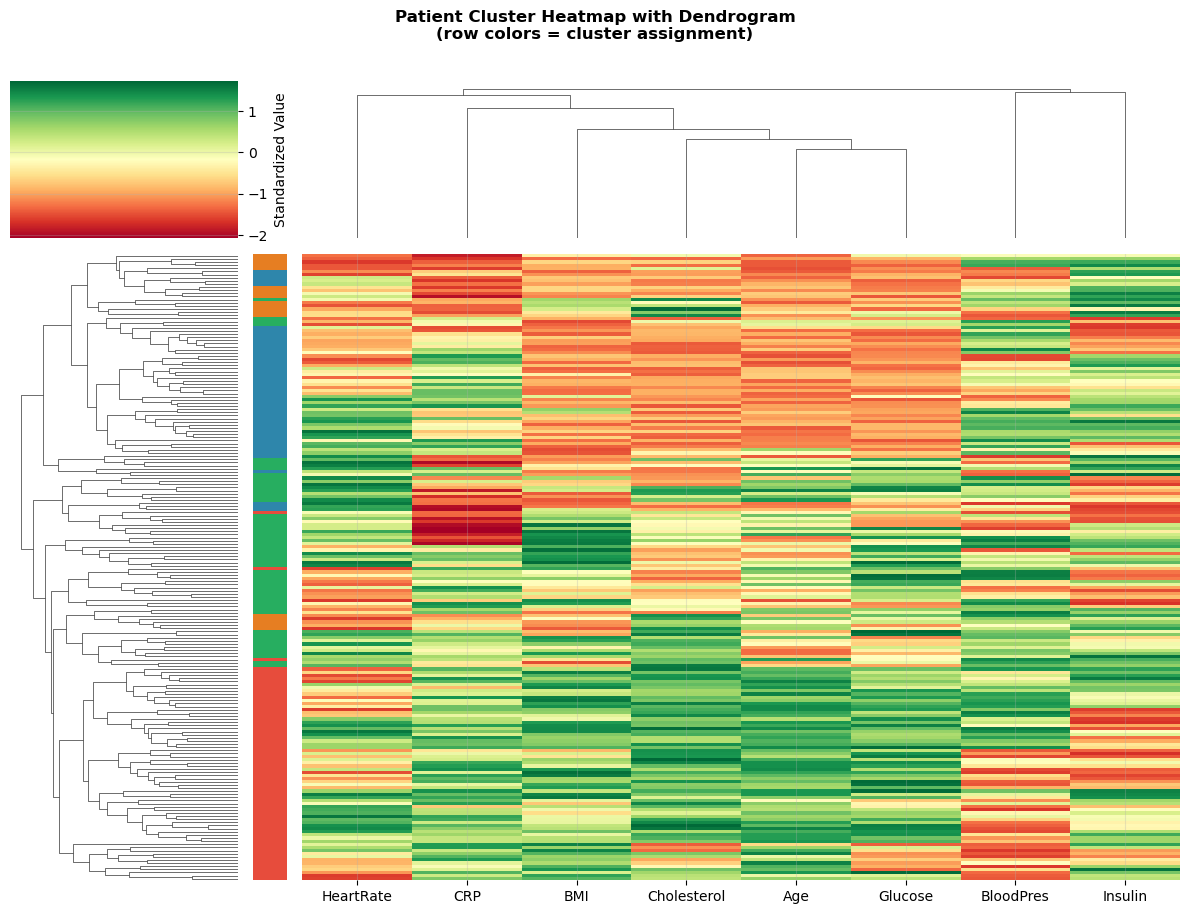

=== Patient Cluster Profiles (original scale means) ===
          Age   BMI  BloodPres  Glucose  Cholesterol  HeartRate  Insulin  CRP
Cluster                                                                      
0        69.4  36.5      103.7    155.6        281.9       80.2    142.9  7.8
1        33.1  22.0      111.2     88.1        149.1       82.3    161.4  5.8
2        50.9  31.9      120.3    143.1        219.0       85.3    143.8  5.1
3        38.8  24.8      115.1    103.7        235.2       62.0    237.5  2.5

Cluster sizes:
Cluster
0    71
1    51
2    59
3    19
Name: count, dtype: int64


In [9]:
# Fit agglomerative clustering with 4 clusters
ac_pat = AgglomerativeClustering(n_clusters=4, linkage='ward')
pat_labels = ac_pat.fit_predict(X_pat_sc)

df_pat = pd.DataFrame(X_pat_sc, columns=feat_names_pat)
df_pat['Cluster'] = pat_labels

# Cluster heatmap using seaborn clustermap
df_heat = df_pat.sort_values('Cluster').drop(columns='Cluster')
row_colors = [CLUSTER_COLORS[c] for c in
              df_pat.sort_values('Cluster')['Cluster']]

g = sns.clustermap(
    df_heat,
    row_cluster=True,
    col_cluster=True,
    cmap='RdYlGn',
    figsize=(12, 9),
    row_colors=row_colors,
    yticklabels=False,
    cbar_kws={'label': 'Standardized Value'}
)
g.fig.suptitle('Patient Cluster Heatmap with Dendrogram\n(row colors = cluster assignment)',
               fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Cluster profile
df_pat_orig = pd.DataFrame(X_pat, columns=feat_names_pat)
df_pat_orig['Cluster'] = pat_labels
print('=== Patient Cluster Profiles (original scale means) ===')
print(df_pat_orig.groupby('Cluster')[feat_names_pat].mean().round(1).to_string())
print()
print('Cluster sizes:')
print(df_pat_orig['Cluster'].value_counts().sort_index())

## 10. Evaluation Metrics

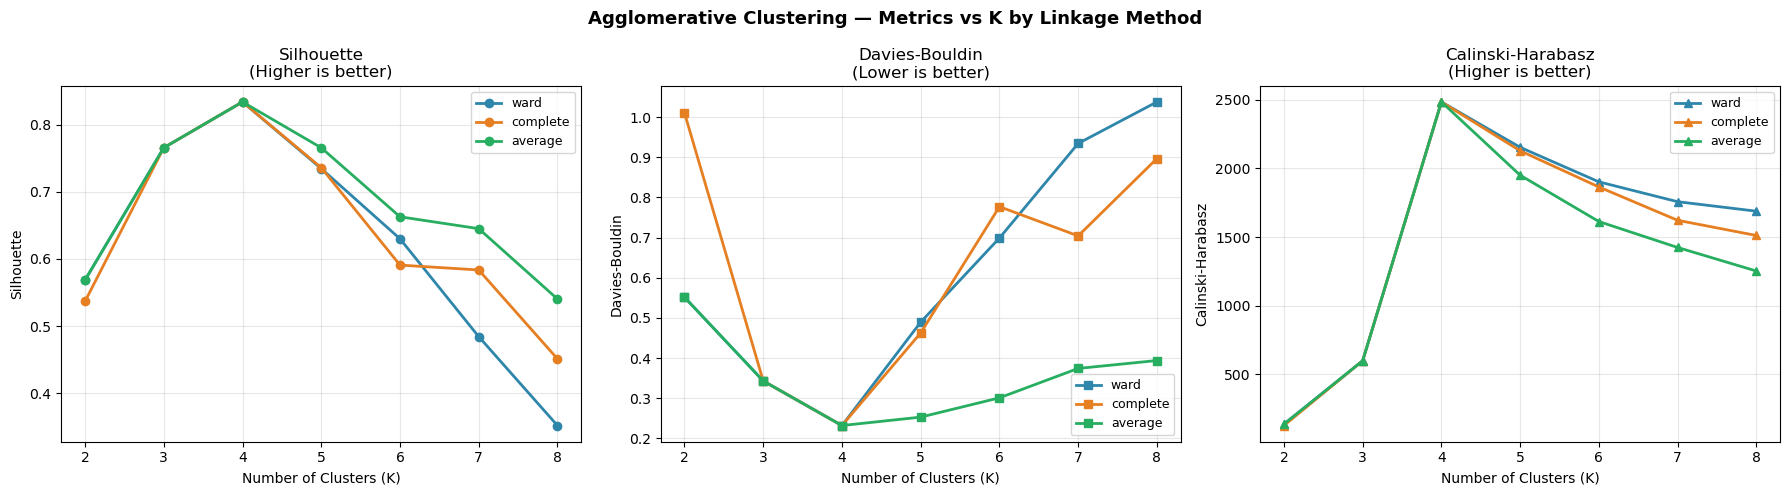

In [10]:
k_range  = range(2, 9)
methods  = ['ward', 'complete', 'average']
colors_m = [COLORS['primary'], COLORS['secondary'], COLORS['success']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metric_names = ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']

for method, color in zip(methods, colors_m):
    sil_scores = []
    db_scores  = []
    ch_scores  = []

    for k in k_range:
        ac = AgglomerativeClustering(n_clusters=k, linkage=method)
        lbl = ac.fit_predict(X_sc)
        sil_scores.append(silhouette_score(X_sc, lbl))
        db_scores.append( davies_bouldin_score(X_sc, lbl))
        ch_scores.append( calinski_harabasz_score(X_sc, lbl))

    axes[0].plot(list(k_range), sil_scores, 'o-', color=color,
                 linewidth=2, markersize=6, label=method)
    axes[1].plot(list(k_range), db_scores,  's-', color=color,
                 linewidth=2, markersize=6, label=method)
    axes[2].plot(list(k_range), ch_scores,  '^-', color=color,
                 linewidth=2, markersize=6, label=method)

for ax, title, tip in zip(axes, metric_names,
                           ['Higher is better','Lower is better','Higher is better']):
    ax.set_xlabel('Number of Clusters (K)')
    ax.set_ylabel(title)
    ax.set_title(f'{title}\n({tip})')
    ax.legend(fontsize=9)

plt.suptitle('Agglomerative Clustering — Metrics vs K by Linkage Method',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. K-Means vs Hierarchical — Head-to-Head

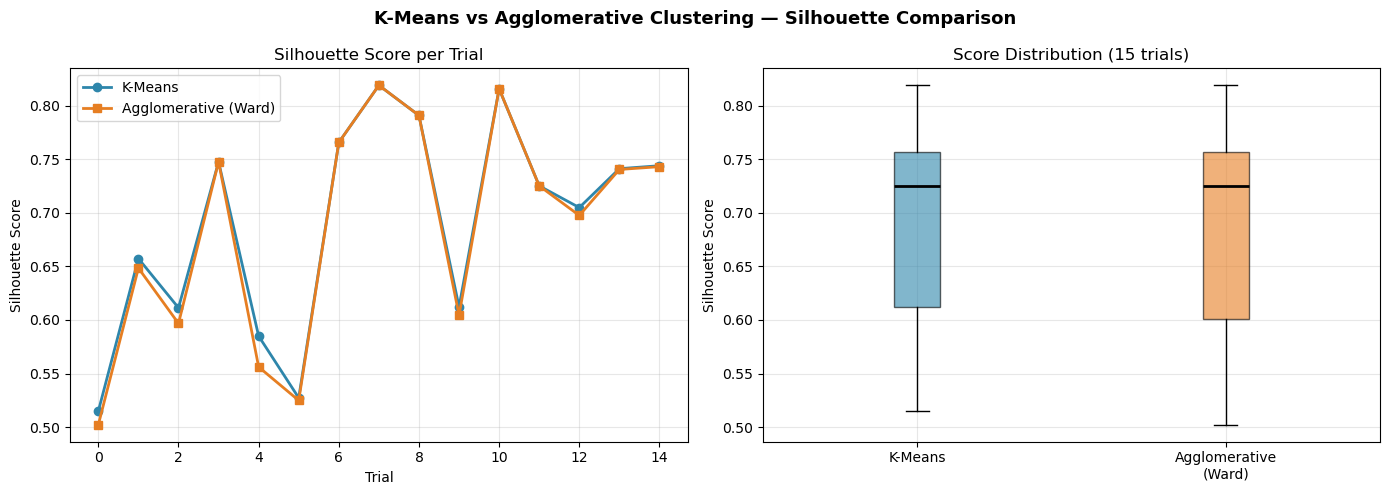

K-Means          Mean=0.6908  Std=0.0966
Agglomerative    Mean=0.6852  Std=0.1020

On spherical blob data both perform similarly.
Hierarchical wins when cluster count is unknown or shapes are irregular.
K-Means wins when data is large (hierarchical is O(n^2) to O(n^3)).


In [11]:
n_trials  = 15
km_scores = []
ac_scores = []

for seed in range(n_trials):
    X_t, _ = make_blobs(n_samples=300, centers=4,
                         cluster_std=0.9, random_state=seed)
    X_t_sc  = StandardScaler().fit_transform(X_t)

    km = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=seed)
    ac = AgglomerativeClustering(n_clusters=4, linkage='ward')

    km_scores.append(silhouette_score(X_t_sc, km.fit_predict(X_t_sc)))
    ac_scores.append(silhouette_score(X_t_sc, ac.fit_predict(X_t_sc)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(km_scores, 'o-', color=COLORS['primary'],
             linewidth=2, markersize=6, label='K-Means')
axes[0].plot(ac_scores, 's-', color=COLORS['secondary'],
             linewidth=2, markersize=6, label='Agglomerative (Ward)')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score per Trial')
axes[0].legend()

bp = axes[1].boxplot([km_scores, ac_scores],
                     labels=['K-Means','Agglomerative\n(Ward)'],
                     patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor(COLORS['primary'])
bp['boxes'][1].set_facecolor(COLORS['secondary'])
for b in bp['boxes']: b.set_alpha(0.6)
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Score Distribution (15 trials)')

plt.suptitle('K-Means vs Agglomerative Clustering — Silhouette Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'K-Means          Mean={np.mean(km_scores):.4f}  Std={np.std(km_scores):.4f}')
print(f'Agglomerative    Mean={np.mean(ac_scores):.4f}  Std={np.std(ac_scores):.4f}')
print()
print('On spherical blob data both perform similarly.')
print('Hierarchical wins when cluster count is unknown or shapes are irregular.')
print('K-Means wins when data is large (hierarchical is O(n^2) to O(n^3)).')

## 12. Final Summary & Key Takeaways

In [12]:
print('=' * 68)
print('          HIERARCHICAL CLUSTERING - KEY TAKEAWAYS')
print('=' * 68)

takeaways = [
    ('Type',              'Agglomerative (bottom-up) most common; divisive (top-down) rare'),
    ('Dendrogram',        'Tree of merges; height = merge cost; cut to get K clusters'),
    ('No K needed',       'Cut the dendrogram at desired height to choose K post-hoc'),
    ('Ward linkage',      'Minimizes variance increase; produces compact equal-size clusters'),
    ('Single linkage',    'Min distance; good for elongated clusters; prone to chaining'),
    ('Complete linkage',  'Max distance; compact clusters; sensitive to outliers'),
    ('Cophenetic corr',   'Measures how well dendrogram preserves pairwise distances'),
    ('Largest gap',       'Auto-select K by finding largest gap in merge heights'),
    ('Clustermap',        'Seaborn clustermap = heatmap + dendrogram for both axes'),
    ('Scaling',           'ALWAYS scale features — uses Euclidean distance by default'),
    ('Deterministic',     'No random init — always produces the same result'),
    ('Complexity',        'O(n^2) memory, O(n^2 log n) time — slow on large datasets'),
    ('vs K-Means',        'More flexible K selection; slower; better for small datasets'),
    ('Next step',         'DBSCAN: density-based, handles noise and arbitrary shapes'),
]

for topic, detail in takeaways:
    print(f'  OK  {topic:<20}  ->  {detail}')

print('=' * 68)

          HIERARCHICAL CLUSTERING - KEY TAKEAWAYS
  OK  Type                  ->  Agglomerative (bottom-up) most common; divisive (top-down) rare
  OK  Dendrogram            ->  Tree of merges; height = merge cost; cut to get K clusters
  OK  No K needed           ->  Cut the dendrogram at desired height to choose K post-hoc
  OK  Ward linkage          ->  Minimizes variance increase; produces compact equal-size clusters
  OK  Single linkage        ->  Min distance; good for elongated clusters; prone to chaining
  OK  Complete linkage      ->  Max distance; compact clusters; sensitive to outliers
  OK  Cophenetic corr       ->  Measures how well dendrogram preserves pairwise distances
  OK  Largest gap           ->  Auto-select K by finding largest gap in merge heights
  OK  Clustermap            ->  Seaborn clustermap = heatmap + dendrogram for both axes
  OK  Scaling               ->  ALWAYS scale features — uses Euclidean distance by default
  OK  Deterministic         ->  No random

---
## Practice Exercises

1. **Try all 4 linkage methods** on the moons dataset — which one recovers the true structure best?
2. **Vary the cut height** on the patient dendrogram and interpret each resulting segmentation.
3. **Compare cophenetic correlations** across linkage methods — which preserves distances best?
4. **Add noise/outliers** to the blob dataset and compare how Ward vs Single linkage respond.
5. **Build a document clustering pipeline** — TF-IDF vectorize text, then hierarchically cluster.
6. **Implement agglomerative clustering from scratch** using only NumPy and a distance matrix.

---
*Notebook created for the ML Repository — Hierarchical Clustering module.*